# CCA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("science_job.csv")

In [3]:
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,NaN,NaN,42.0,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,NaN,NaN,52.0,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,50-99,Pvt Ltd,44.0,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,0.0,500-999,Pvt Ltd,97.0,0.0


In [4]:
df.isnull()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,False,False,False,False,False,False,False,False,False,True,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,True,True,False,False
3,False,False,False,True,False,True,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,False,False,False,False,False,False,False,False,False,True,True,False,False
19154,False,False,False,False,False,False,False,False,False,True,True,False,False
19155,False,False,False,False,False,False,False,False,False,False,False,False,False
19156,False,False,False,False,False,False,False,True,False,False,False,False,False


In [6]:
df.isnull().mean() * 100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [7]:
col = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]

In [8]:
df[col].sample(10)

,city_development_index,enrolled_university,education_level,experience,training_hours
16097,0.920,no_enrollment,Graduate,7.0,97.0
10994,0.624,Full time course,Masters,8.0,41.0
10945,0.754,no_enrollment,Graduate,9.0,11.0
18847,0.624,no_enrollment,Masters,10.0,96.0
15722,0.740,no_enrollment,Masters,14.0,196.0
8558,0.624,NaN,Graduate,3.0,52.0
3385,0.924,Full time course,High School,3.0,17.0
16386,0.910,no_enrollment,Graduate,0.0,15.0
7801,0.925,Part time course,Masters,9.0,23.0
2573,0.766,Part time course,Graduate,9.0,112.0


In [10]:
len(df[col].dropna()) / len(df[col])

0.8968577095730244

In [11]:
new_df = df[col].dropna()

df.shape , new_df.shape

((19158, 13), (17182, 5))

### **If you have numerical data , you have to apply histrogram before cca and after cca**

<Axes: >

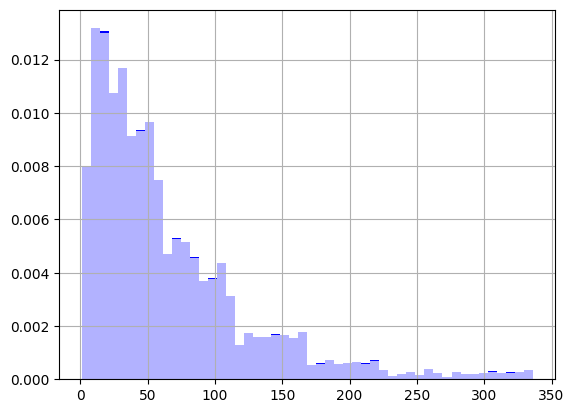

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='blue')

# data after cca
new_df['training_hours'].hist(bins=50, ax=ax, color='white', density=True, alpha=0.7)

<Axes: ylabel='Density'>

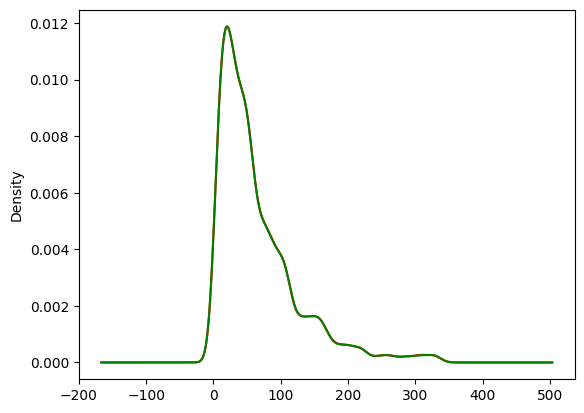

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

### **If you have categorical data , you have to check the ration of specific categories before cca and after cca**

In [14]:
df[col].sample(10)

,city_development_index,enrolled_university,education_level,experience,training_hours
1825,0.926,no_enrollment,Graduate,16.0,56.0
14171,0.624,Full time course,Graduate,18.0,44.0
1434,0.698,NaN,NaN,3.0,37.0
5269,0.910,no_enrollment,NaN,5.0,NaN
10606,0.939,no_enrollment,Graduate,14.0,112.0
6214,0.920,NaN,Graduate,10.0,10.0
17630,0.897,no_enrollment,Phd,18.0,256.0
9745,0.897,no_enrollment,Masters,10.0,60.0
3114,0.897,no_enrollment,Masters,6.0,18.0
14518,NaN,no_enrollment,Graduate,20.0,6.0


In [15]:
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [17]:
# Original Data
df['enrolled_university'].value_counts()/ len(df)

enrolled_university
no_enrollment       0.721213
Full time course    0.196106
Part time course    0.062533
Name: count, dtype: float64

In [18]:
# After CCA data
new_df['enrolled_university'].value_counts()/ len(new_df)

enrolled_university
no_enrollment       0.735188
Full time course    0.200733
Part time course    0.064079
Name: count, dtype: float64

In [19]:
# Original Data
df['education_level'].value_counts()/ len(df)

education_level
Graduate          0.605387
Masters           0.227633
High School       0.105282
Phd               0.021610
Primary School    0.016077
Name: count, dtype: float64

In [21]:
# After CCA data
new_df['education_level'].value_counts()/ len(new_df)

education_level
Graduate          0.619835
Masters           0.234082
High School       0.107380
Phd               0.022116
Primary School    0.016587
Name: count, dtype: float64

# Mean / Median Imputation

In [23]:
df = pd.read_csv("titanic_dem.csv")

In [24]:
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [26]:
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [27]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [30]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [31]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [34]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

In [36]:
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)
X_train['Age_median'] = X_train['Age'].fillna(median_age)


In [37]:
X_train

,Age,Fare,Family,Age_mean,Age_medain,Age_median
30,40.0,27.7208,0,40.000000,40.00,40.00
10,4.0,16.7000,2,4.000000,4.00,4.00
873,47.0,9.0000,0,47.000000,47.00,47.00
182,9.0,31.3875,6,9.000000,9.00,9.00
876,20.0,9.8458,0,20.000000,20.00,20.00
...,...,...,...,...,...,...
534,30.0,8.6625,0,30.000000,30.00,30.00
584,NaN,8.7125,0,29.785904,28.75,28.75
493,71.0,49.5042,0,71.000000,71.00,71.00
527,NaN,221.7792,0,29.785904,28.75,28.75


In [39]:
mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [40]:
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)
X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)


In [41]:
X_train

,Age,Fare,Family,Age_mean,Age_medain,Age_median,Fare_mean,Fare_median
30,40.0,27.7208,0,40.000000,40.00,40.00,27.7208,27.7208
10,4.0,16.7000,2,4.000000,4.00,4.00,16.7000,16.7000
873,47.0,9.0000,0,47.000000,47.00,47.00,9.0000,9.0000
182,9.0,31.3875,6,9.000000,9.00,9.00,31.3875,31.3875
876,20.0,9.8458,0,20.000000,20.00,20.00,9.8458,9.8458
...,...,...,...,...,...,...,...,...
534,30.0,8.6625,0,30.000000,30.00,30.00,8.6625,8.6625
584,NaN,8.7125,0,29.785904,28.75,28.75,8.7125,8.7125
493,71.0,49.5042,0,71.000000,71.00,71.00,49.5042,49.5042
527,NaN,221.7792,0,29.785904,28.75,28.75,221.7792,221.7792


In [42]:
X_train.corr()

,Age,Fare,Family,Age_mean,Age_medain,Age_median,Fare_mean,Fare_median
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,1.000000,0.090156,0.087356
Fare,0.092644,1.000000,0.208268,0.088069,0.091757,0.091757,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.244610,-0.242883,-0.242883,0.205499,0.205942
Age_mean,1.000000,0.088069,-0.244610,1.000000,0.999454,0.999454,0.086078,0.083461
Age_medain,1.000000,0.091757,-0.242883,0.999454,1.000000,1.000000,0.089673,0.086982
Age_median,1.000000,0.091757,-0.242883,0.999454,1.000000,1.000000,0.089673,0.086982
Fare_mean,0.090156,1.000000,0.205499,0.086078,0.089673,0.089673,1.000000,0.996607
Fare_median,0.087356,1.000000,0.205942,0.083461,0.086982,0.086982,0.996607,1.000000


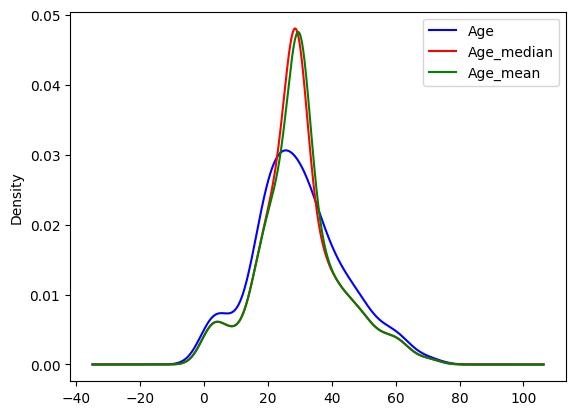

In [43]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax, color='blue')

# variable imputed with the median
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

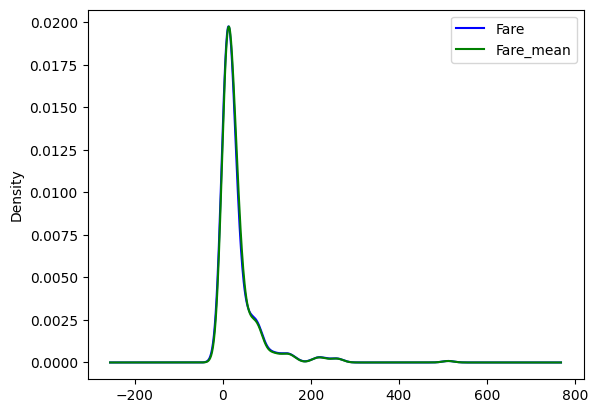

In [44]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax, color='blue')

# variable imputed with the median
# X_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

<Axes: >

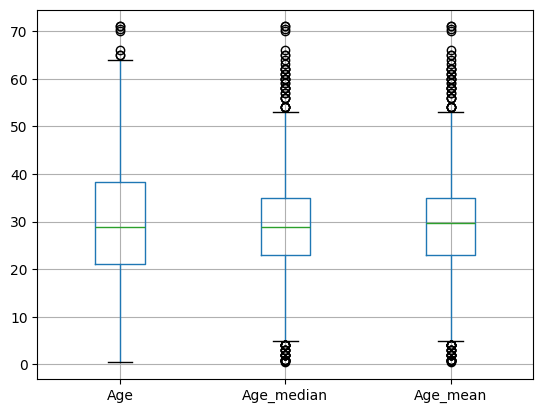

In [45]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

<Axes: >

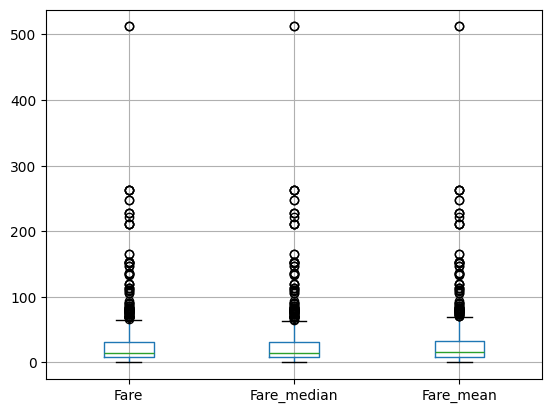

In [46]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

# Arbitary

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [53]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

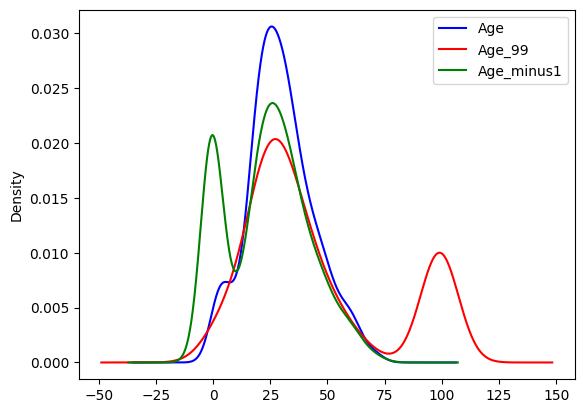

In [54]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax, color='blue')

# variable imputed with the median
X_train['Age_99'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

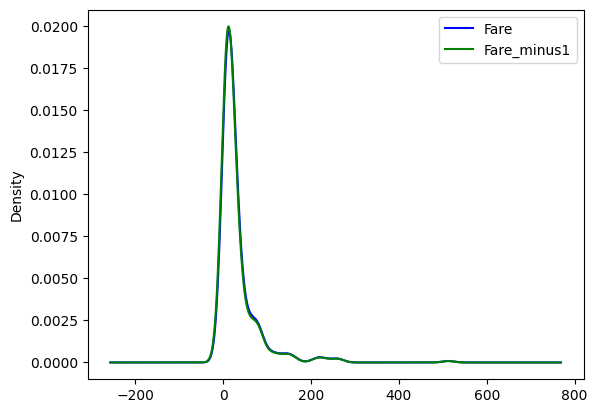

In [55]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax, color='blue')

# variable imputed with the median
# X_train['Fare_999'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Fare_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

# Random value

In [56]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [57]:
X_train['Age_imputed'] = X_train['Age']

In [58]:
X_train

,Age,Fare,Family,Age_imputed
30,40.0,27.7208,0,40.0
10,4.0,16.7000,2,4.0
873,47.0,9.0000,0,47.0
182,9.0,31.3875,6,9.0
876,20.0,9.8458,0,20.0
...,...,...,...,...
534,30.0,8.6625,0,30.0
584,NaN,8.7125,0,NaN
493,71.0,49.5042,0,71.0
527,NaN,221.7792,0,NaN


In [59]:
m = X_train['Age_imputed'].isnull()

In [60]:
X_train.loc[m,  "Age_imputed"]

77    NaN
868   NaN
334   NaN
295   NaN
792   NaN
       ..
674   NaN
466   NaN
584   NaN
527   NaN
168   NaN
Name: Age_imputed, Length: 148, dtype: float64

In [61]:
X_train['Age'].dropna()

30     40.0
10      4.0
873    47.0
182     9.0
876    20.0
       ... 
360    40.0
75     25.0
299    50.0
534    30.0
493    71.0
Name: Age, Length: 564, dtype: float64

In [62]:
X_train['Age'].dropna().sample(m.sum(), random_state=2).values

array([23.  , 44.  , 28.  , 19.  , 21.  , 36.  ,  7.  , 38.  , 45.  ,
       49.  , 36.  , 21.  , 28.  , 45.  , 34.  , 37.  , 47.  , 23.  ,
       40.  ,  0.42, 43.  , 52.  , 35.  , 45.5 , 32.  , 26.  ,  4.  ,
       24.  , 34.  , 32.  , 18.  , 33.  , 28.  , 39.  , 28.  , 41.  ,
        2.  , 59.  , 17.  , 15.  , 30.  ,  8.  , 17.  , 27.  , 45.  ,
       24.  , 20.  , 40.5 , 50.  ,  2.  , 30.  , 30.  , 18.  ,  5.  ,
       29.  ,  0.75, 25.  ,  9.  , 32.5 ,  9.  , 33.  , 25.  , 25.  ,
       34.  , 51.  , 48.  , 39.  , 31.  ,  1.  , 54.  , 30.  , 24.  ,
       21.  , 42.  , 30.  , 30.  , 39.  , 43.  , 27.  , 36.  , 27.  ,
       60.  , 19.  ,  9.  , 18.  ,  2.  , 16.  , 61.  , 60.  , 31.  ,
       24.  , 34.5 , 33.  , 39.  , 24.  , 48.  , 36.  , 25.  , 16.  ,
       34.  , 13.  , 36.  , 54.  ,  3.  , 66.  , 27.  , 23.  , 22.  ,
       36.5 , 21.  , 34.  , 45.  , 14.  ,  4.  ,  5.  , 21.  , 30.  ,
       60.  , 21.  , 31.  , 30.  , 29.  , 16.  , 25.  , 30.  , 24.  ,
       50.  , 33.  ,

In [63]:
X_train.loc[m,  "Age_imputed"] = (
    X_train['Age'].dropna().sample(m.sum(), random_state=2).values
)

In [64]:
X_train

,Age,Fare,Family,Age_imputed
30,40.0,27.7208,0,40.0
10,4.0,16.7000,2,4.0
873,47.0,9.0000,0,47.0
182,9.0,31.3875,6,9.0
876,20.0,9.8458,0,20.0
...,...,...,...,...
534,30.0,8.6625,0,30.0
584,NaN,8.7125,0,22.0
493,71.0,49.5042,0,71.0
527,NaN,221.7792,0,24.0


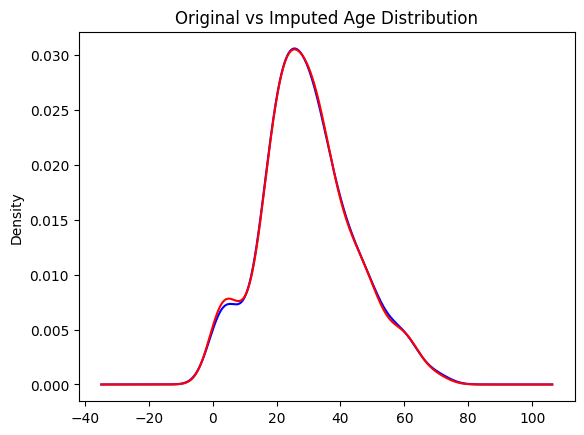

In [65]:

fig = plt.figure()
ax = fig.add_subplot(111)

# original distribution
X_train['Age'].plot(kind='kde', ax=ax, color='blue')

# imputed distribution
X_train['Age_imputed'].plot(kind='kde', ax=ax, color='red')


plt.title("Original vs Imputed Age Distribution")
plt.show()

# Frequent_value_imputation

In [67]:
df = pd.read_csv("train.csv", usecols=['GarageQual','FireplaceQu','SalePrice'])
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [68]:
df.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

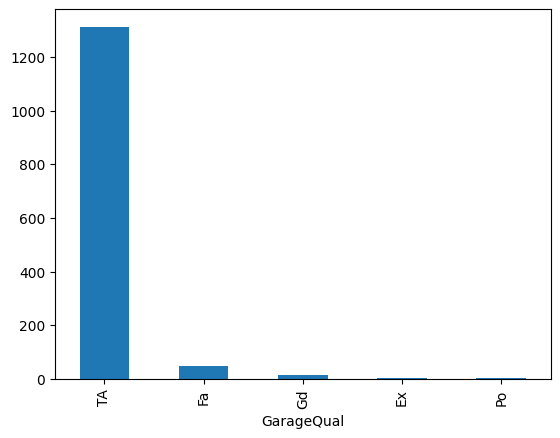

In [69]:
df['GarageQual'].value_counts().plot(kind='bar')

In [70]:
df['GarageQual'].mode().values[0]

'TA'

In [71]:
df['GarageQual_imputed'] = df['GarageQual'].fillna(df['GarageQual'].mode().values[0])

In [72]:
df

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed
0,NaN,TA,208500,TA
1,TA,TA,181500,TA
2,TA,TA,223500,TA
3,Gd,TA,140000,TA
4,TA,TA,250000,TA
...,...,...,...,...
1455,TA,TA,175000,TA
1456,TA,TA,210000,TA
1457,Gd,TA,266500,TA
1458,NaN,TA,142125,TA


<Axes: xlabel='GarageQual_imputed'>

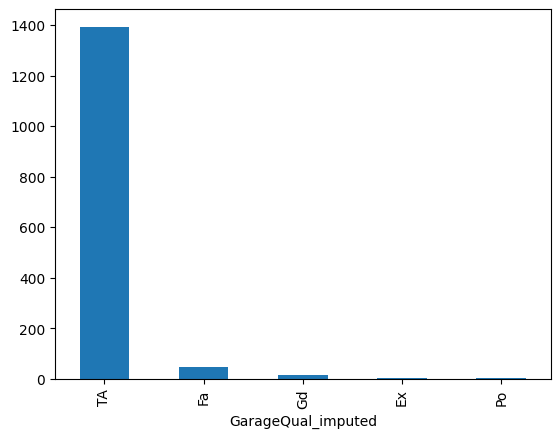

In [73]:
df['GarageQual_imputed'].value_counts().plot(kind='bar')